In [1]:
print("hello world")

hello world


In [3]:
# ============================================================
# BANK STRESS MONITOR
# Phase 2: Data Collection, Cleaning & Ratio Calculation
# ============================================================
# Author:      Juhi Shah
# Date:        March 2026
# Data Source: FDIC BankFind Suite Public API
#              banks.data.fdic.gov
# Description: Pulls quarterly call report data for all
#              active US banks, calculates 10 stress ratios
#              across 5 risk categories, and produces a
#              clean scored dataset for Phase 3 modeling
# ============================================================
#
# 10 STRESS RATIOS:
#   1. Leverage Ratio          — Solvency
#   2. Texas Ratio             — Asset Quality
#   3. Securities / Assets     — Rate Risk
#   4. Uninsured Deposits %    — Run Risk
#   5. Return on Assets        — Profitability
#   6. Loan-to-Deposit Ratio   — Liquidity (Structural)
#   7. CRE / Total Capital     — Concentration Risk
#   8. NIM Ratio               — Earnings Quality
#   9. Cash / Assets           — Liquidity (Crisis Buffer)
#  10. Borrowings / Assets     — Funding Stability
#
# ============================================================

import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")
print(f"pandas version:  {pd.__version__}")
print(f"numpy version:   {np.__version__}")

All libraries imported successfully
pandas version:  2.2.2
numpy version:   1.26.4


In [5]:
# ============================================================
# CELL 2: PULL ACTIVE INSTITUTION DATA
# ============================================================
# Source:  FDIC /api/institutions endpoint
# Purpose: Get bank names, cities, states for all active
#          US banks — used to identify and remove inactive
#          institutions after merge
# Fields:  CERT (unique key), NAME, CITY, STNAME, ASSET
# Note:    ACTIVE:1 filter pulls currently active banks only
#          4,300+ records expected
# ============================================================

url_inst = "https://banks.data.fdic.gov/api/institutions"

params_inst = {
    "filters": "ACTIVE:1",
    "fields": "CERT,NAME,CITY,STNAME,ASSET",
    "limit": 10000,
    "offset": 0,
    "output": "json"
}

response_inst = requests.get(url_inst, params=params_inst)
data_inst = response_inst.json()
institutions_df = pd.DataFrame([item["data"] for item in data_inst["data"]])

# Convert asset to numeric
institutions_df['ASSET'] = pd.to_numeric(institutions_df['ASSET'], errors='coerce')

print(f"Active institutions pulled: {len(institutions_df)}")
print(f"Columns: {list(institutions_df.columns)}")
institutions_df.head()

Active institutions pulled: 4317
Columns: ['CITY', 'STNAME', 'ASSET', 'CERT', 'NAME', 'ID']


,CITY,STNAME,ASSET,CERT,NAME,ID
0,Markesan,Wisconsin,261034.0,10004,Ergo Bank,10004
1,Monroe,Wisconsin,509049.0,10011,Woodford State Bank,10011
2,Almond,Wisconsin,215689.0,10012,The Portage County Bank,10012
3,New Auburn,Wisconsin,231630.0,10015,Security Bank,10015
4,Fond Du Lac,Wisconsin,2920038.0,10044,National Exchange Bank and Trust,10044


In [7]:
# ============================================================
# CELL 3: PULL FINANCIAL DATA — 20 RAW FIELDS
# ============================================================
# Source:  FDIC /api/financials endpoint
# Purpose: Pull all raw fields needed to calculate
#          10 stress ratios for year-end 2025
# Date:    20251231 (most recent full year available)
# Fields:  20 confirmed fields — all tested and validated
#
# FIELD REFERENCE:
# --- Identifiers ---
# CERT      Unique bank certificate number
# REPDTE    Reporting date
# --- Balance Sheet ---
# ASSET     Total assets
# DEP       Total deposits
# DEPUNINS  Uninsured deposits
# LNLSGR    Total loans (gross)
# SC        Total securities (fair value)
# EQTOT     Total equity
# INTAN     Intangible assets
# CHBAL     Cash and balances due
# OTHBRF    Other borrowed funds
# --- Capital ---
# RBCT1J    Tier 1 capital
# RBCT2     Tier 2 capital
# --- Asset Quality ---
# LNATRES   Allowance for credit losses
# NAASSET   Non-accrual loans
# P9ASSET   Loans 90+ days past due
# ORE       Foreclosed real estate (OREO)
# --- CRE Loans ---
# LNRECONS  CRE construction loans
# LNRENRES  CRE non-residential loans
# --- Income ---
# NETINC    Net income
# NIM       Net interest income (dollar amount)
# ============================================================

url_fin = "https://banks.data.fdic.gov/api/financials"

fields = [
    "CERT", "REPDTE",
    # Balance Sheet
    "ASSET", "DEP", "DEPUNINS", "LNLSGR", "SC",
    "EQTOT", "INTAN", "CHBAL", "OTHBRF",
    # Capital
    "RBCT1J", "RBCT2",
    # Asset Quality
    "LNATRES", "NAASSET", "P9ASSET", "ORE",
    # CRE Loans
    "LNRECONS", "LNRENRES",
    # Income
    "NETINC", "NIM",
]

params_fin = {
    "fields": ",".join(fields),
    "filters": "REPDTE:20251231",
    "limit": 10000,
    "offset": 0,
    "output": "json"
}

response_fin = requests.get(url_fin, params=params_fin)
data_fin = response_fin.json()
financials_df = pd.DataFrame([item["data"] for item in data_fin["data"]])

print(f"Banks with financial data: {len(financials_df)}")
print(f"Fields returned: {len(financials_df.columns)}")
print(f"Reporting date: {financials_df['REPDTE'].unique()}")
print(f"Columns: {list(financials_df.columns)}")

Banks with financial data: 4408
Fields returned: 22
Reporting date: ['20251231']
Columns: ['ORE', 'OTHBRF', 'LNATRES', 'REPDTE', 'ASSET', 'LNLSGR', 'NETINC', 'DEP', 'SC', 'NAASSET', 'RBCT2', 'NIM', 'DEPUNINS', 'RBCT1J', 'INTAN', 'P9ASSET', 'CHBAL', 'LNRENRES', 'CERT', 'LNRECONS', 'EQTOT', 'ID']


In [9]:
# ============================================================
# CELL 4: MERGE INSTITUTION NAMES WITH FINANCIAL DATA
# ============================================================
# Method:  Left join financials onto institutions on CERT
#          Equivalent to VLOOKUP in Excel — matching on
#          unique bank certificate number
# Result:  All 4,408 financial records retained
#          Banks without a name match will show NaN —
#          these will be identified as inactive in Cell 6
# ============================================================

df = pd.merge(
    financials_df,
    institutions_df[['CERT', 'NAME', 'CITY', 'STNAME']],
    on='CERT',
    how='left'
)

# Convert all numeric fields to float
# errors='coerce' turns invalid strings into NaN
numeric_cols = [
    'ASSET', 'DEP', 'DEPUNINS', 'LNLSGR', 'NETINC', 'SC',
    'EQTOT', 'INTAN', 'CHBAL', 'OTHBRF', 'RBCT1J', 'RBCT2',
    'LNATRES', 'NAASSET', 'P9ASSET', 'ORE', 'LNRECONS',
    'LNRENRES', 'NIM'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Total records after merge:       {len(df)}")
print(f"Banks with name matched:         {df['NAME'].notna().sum()}")
print(f"Banks without name (inactive):   {df['NAME'].isna().sum()}")
print(f"\nSample — first 5 banks:")
df[['CERT', 'NAME', 'CITY', 'STNAME', 'ASSET']].head()

Total records after merge:       4408
Banks with name matched:         4303
Banks without name (inactive):   105

Sample — first 5 banks:


,CERT,NAME,CITY,STNAME,ASSET
0,10004,Ergo Bank,Markesan,Wisconsin,261034
1,10011,Woodford State Bank,Monroe,Wisconsin,509049
2,10012,The Portage County Bank,Almond,Wisconsin,215689
3,10015,Security Bank,New Auburn,Wisconsin,231630
4,10044,National Exchange Bank and Trust,Fond Du Lac,Wisconsin,2920038


In [11]:
# ============================================================
# CELL 5: REMOVE INACTIVE BANKS
# ============================================================
# Purpose: Remove 105 banks with missing names
# Reason:  Investigation confirmed all unmatched banks are
#          inactive/closed institutions that filed a final
#          call report but are no longer operating
#          (ACTIVE=0 confirmed via FDIC institutions endpoint)
# Examples removed: Cadence Bank, Standard Chartered,
#                   BBVA, MashreqBank — all closed US charters
# Impact:  105 records removed, 4,303 active banks remain
# Note:    This step must happen AFTER the merge so we can
#          identify inactive banks via missing name field
# ============================================================

before = len(df)

# Remove banks with missing names — confirmed inactive
df = df[df['NAME'].notna()].copy()
df = df.reset_index(drop=True)

after = len(df)

print(f"Banks before removal: {before}")
print(f"Banks removed:        {before - after}")
print(f"Active banks:         {after}")

Banks before removal: 4408
Banks removed:        105
Active banks:         4303


In [13]:
# ============================================================
# CELL 6: SIZE TIER SEGMENTATION
# ============================================================
# Purpose: Segment banks into 4 regulatory size tiers
#          Percentile scoring and outlier capping will be
#          calculated WITHIN tiers for fair peer comparison
#
# Tiers based on total assets (ASSET in $thousands):
#   Community:      < $1B    ($0 - $999,999K)
#   Mid-Size:       $1B-$10B ($1,000,000 - $9,999,999K)
#   Large Regional: $10B-$100B ($10,000,000 - $99,999,999K)
#   Large:          > $100B  ($100,000,000K+)
#
# Note: Must happen AFTER inactive bank removal so tiers
#       reflect the clean active bank population only
#       Must happen BEFORE outlier capping so caps are
#       calculated within correct peer groups
# ============================================================

def assign_size_tier(asset):
    if pd.isna(asset):
        return 'Unknown'
    elif asset < 1_000_000:
        return 'Community'
    elif asset < 10_000_000:
        return 'Mid-Size'
    elif asset < 100_000_000:
        return 'Large Regional'
    else:
        return 'Large'

df['SIZE_TIER'] = df['ASSET'].apply(assign_size_tier)

# Distribution summary
print("=" * 65)
print("BANK DISTRIBUTION BY SIZE TIER")
print("=" * 65)
print(f"{'Tier':<20} {'Count':>6} {'%':>6} {'Median Assets':>20}")
print("-" * 65)

tier_order = ['Community', 'Mid-Size', 'Large Regional', 'Large']
total = len(df)

for tier in tier_order:
    count = (df['SIZE_TIER'] == tier).sum()
    pct = 100 * count / total
    median_assets = df[df['SIZE_TIER'] == tier]['ASSET'].median()
    median_str = f"${median_assets/1_000_000:,.2f}B"
    print(f"{tier:<20} {count:>6} {pct:>5.1f}% {median_str:>20}")

print("-" * 65)
print(f"{'TOTAL':<20} {total:>6} {100.0:>5.1f}%")

BANK DISTRIBUTION BY SIZE TIER
Tier                  Count      %        Median Assets
-----------------------------------------------------------------
Community              3262  75.8%               $0.26B
Mid-Size                888  20.6%               $2.01B
Large Regional          122   2.8%              $23.65B
Large                    31   0.7%             $252.07B
-----------------------------------------------------------------
TOTAL                  4303 100.0%


In [15]:
# ============================================================
# CELL 7: HANDLE MISSING VALUES — PRE-CALCULATION
# ============================================================
# Purpose: Fill specific fields with zero where missing
#          before ratio calculation
#
# ASSUMPTION DOCUMENTATION:
# INTAN   → 0: No intangibles reported = no adjustment to
#               equity needed. Conservative assumption —
#               slightly overstates TCE for banks with
#               unreported intangibles
# RBCT2   → 0: Many community banks have no Tier 2 capital
#               Zero is legitimate, not missing data
# P9ASSET → 0: No loans 90+ days past due = legitimate
#               for healthy banks in current environment
# ORE     → 0: No foreclosed real estate = legitimate
#               Most healthy banks hold no OREO currently
# OTHBRF  → 0: No wholesale borrowing = legitimate
#               Many community banks are purely deposit-funded
#
# Note: These fields have zeros as genuine data points —
#       filling NaN with zero is the correct assumption
#       Fields NOT filled here (ASSET, DEP, RBCT1J etc.)
#       will remain NaN if missing — banks missing core
#       fields will get NaN ratios and low completeness scores
# ============================================================

fill_zero_cols = ['INTAN', 'RBCT2', 'P9ASSET', 'ORE', 'OTHBRF']

for col in fill_zero_cols:
    null_before = df[col].isna().sum()
    df[col] = df[col].fillna(0)
    null_after = df[col].isna().sum()
    print(f"{col:<12}: {null_before:>4} nulls filled with 0 "
          f"→ {null_after} remaining")

print(f"\nMissing value treatment complete")

INTAN       :    9 nulls filled with 0 → 0 remaining
RBCT2       :    9 nulls filled with 0 → 0 remaining
P9ASSET     :    0 nulls filled with 0 → 0 remaining
ORE         :    9 nulls filled with 0 → 0 remaining
OTHBRF      :    0 nulls filled with 0 → 0 remaining

Missing value treatment complete


In [17]:
# ============================================================
# CELL 8: RAW DATA QUALITY DIAGNOSTIC
# ============================================================
# Purpose: Document data quality BEFORE ratio calculation
#          Professional practice — understand your data
#          before modeling it
# Checks:  Valid %, nulls, zeros, infinities, and median
#          for all 19 numeric fields across 4 size tiers
# Note:    This is documentation only — no data is changed
#          here. Findings inform methodology decisions
#          documented in the methodology notes
# ============================================================

print("=" * 70)
print("RAW DATA QUALITY DIAGNOSTIC")
print("=" * 70)

diagnostic_cols = [
    'ASSET', 'DEP', 'DEPUNINS', 'LNLSGR', 'NETINC', 'SC',
    'EQTOT', 'INTAN', 'CHBAL', 'OTHBRF', 'RBCT1J', 'RBCT2',
    'LNATRES', 'NAASSET', 'P9ASSET', 'ORE',
    'LNRECONS', 'LNRENRES', 'NIM'
]

tier_order = ['Community', 'Mid-Size', 'Large Regional', 'Large']

for col in diagnostic_cols:
    print(f"\n{col}:")
    print(f"  {'Tier':<20} {'Valid%':>7} {'Nulls':>6} "
          f"{'Zeros':>6} {'Median':>15}")
    print(f"  {'-'*58}")

    for tier in tier_order:
        tier_data = df[df['SIZE_TIER'] == tier][col]
        total = len(tier_data)
        nulls = tier_data.isna().sum()
        zeros = (tier_data == 0).sum()
        valid = total - nulls - zeros
        valid_pct = 100 * valid / total

        valid_vals = tier_data.dropna()
        valid_vals = valid_vals[valid_vals != 0]
        median_str = (f"{valid_vals.median():>15,.0f}"
                      if len(valid_vals) > 0 else "            N/A")

        print(f"  {tier:<20} {valid_pct:>6.1f}% {nulls:>6} "
              f"{zeros:>6} {median_str}")

print("\n" + "=" * 70)
print("RAW DIAGNOSTIC COMPLETE")
print("=" * 70)

RAW DATA QUALITY DIAGNOSTIC

ASSET:
  Tier                  Valid%  Nulls  Zeros          Median
  ----------------------------------------------------------
  Community             100.0%      0      0         263,442
  Mid-Size              100.0%      0      0       2,010,160
  Large Regional        100.0%      0      0      23,648,324
  Large                 100.0%      0      0     252,074,150

DEP:
  Tier                  Valid%  Nulls  Zeros          Median
  ----------------------------------------------------------
  Community              99.9%      0      2         219,926
  Mid-Size              100.0%      0      0       1,681,706
  Large Regional        100.0%      0      0      19,983,958
  Large                 100.0%      0      0     196,979,273

DEPUNINS:
  Tier                  Valid%  Nulls  Zeros          Median
  ----------------------------------------------------------
  Community              99.8%      0      8          48,780
  Mid-Size              100.0%  

In [19]:
# ============================================================
# CELL 9: CALCULATE 10 STRESS RATIOS
# ============================================================
# Purpose: Derive all stress metrics from raw FDIC fields
#
# RATIO REFERENCE:
#  1. LEVERAGE_RATIO      = RBCT1J / ASSET
#  2. TEXAS_RATIO         = (NAASSET + P9ASSET + ORE) /
#                           (EQTOT - INTAN + LNATRES)
#  3. SECURITIES_RATIO    = SC / ASSET
#  4. UNINSURED_DEP_RATIO = DEPUNINS / DEP
#  5. ROA                 = NETINC / ASSET
#  6. LTD_RATIO           = LNLSGR / DEP
#  7. CRE_RATIO           = (LNRECONS + LNRENRES) /
#                           (RBCT1J + RBCT2)
#  8. NIM_RATIO           = NIM / ASSET
#  9. CASH_RATIO          = CHBAL / ASSET
# 10. BORROW_RATIO        = OTHBRF / ASSET
#
# STRESS DIRECTION:
#  LOW  = more stressed: LEVERAGE, ROA, NIM, CASH
#  HIGH = more stressed: TEXAS, SECURITIES, UNINSURED_DEP,
#                        LTD, CRE, BORROW
#
# METHODOLOGY NOTES:
#  - NIM uses NIM/ASSET not earning assets — documented
#    limitation, consistent across all banks, validated
#    against JPMorgan, Flagstar, Metro City Bank
#  - INTAN approximated as 0 where unreported —
#    slightly overstates TCE for affected banks
#  - Raw ratios retained before cleaning for audit trail
# ============================================================

# Work on a copy to preserve raw data
ratios_df = df.copy()

# --- Intermediate calculations ---
ratios_df['NPA'] = (ratios_df['NAASSET'] +
                    ratios_df['P9ASSET'] +
                    ratios_df['ORE'])

ratios_df['TCE'] = ratios_df['EQTOT'] - ratios_df['INTAN']

ratios_df['TOTAL_CAP'] = ratios_df['RBCT1J'] + ratios_df['RBCT2']

ratios_df['CRE_LOANS'] = (ratios_df['LNRECONS'] +
                           ratios_df['LNRENRES'])

# --- Ratio 1: Leverage Ratio ---
ratios_df['LEVERAGE_RATIO'] = (ratios_df['RBCT1J'] /
                                ratios_df['ASSET'])

# --- Ratio 2: Texas Ratio ---
ratios_df['TEXAS_RATIO'] = (ratios_df['NPA'] /
                             (ratios_df['TCE'] +
                              ratios_df['LNATRES']))

# --- Ratio 3: Securities / Total Assets ---
ratios_df['SECURITIES_RATIO'] = (ratios_df['SC'] /
                                  ratios_df['ASSET'])

# --- Ratio 4: Uninsured Deposits % ---
ratios_df['UNINSURED_DEP_RATIO'] = (ratios_df['DEPUNINS'] /
                                     ratios_df['DEP'])

# --- Ratio 5: Return on Assets ---
ratios_df['ROA'] = (ratios_df['NETINC'] /
                    ratios_df['ASSET'])

# --- Ratio 6: Loan-to-Deposit Ratio ---
ratios_df['LTD_RATIO'] = (ratios_df['LNLSGR'] /
                           ratios_df['DEP'])

# --- Ratio 7: CRE / Total Capital ---
ratios_df['CRE_RATIO'] = (ratios_df['CRE_LOANS'] /
                           ratios_df['TOTAL_CAP'])

# --- Ratio 8: NIM Ratio ---
# Note: NIM field = net interest income in $thousands
# Dividing by ASSET gives return on assets from interest
# Validated: consistent with published figures within
# acceptable tolerance (avg gap 0.4% vs published NIM)
ratios_df['NIM_RATIO'] = (ratios_df['NIM'] /
                           ratios_df['ASSET'])

# --- Ratio 9: Cash / Total Assets ---
ratios_df['CASH_RATIO'] = (ratios_df['CHBAL'] /
                            ratios_df['ASSET'])

# --- Ratio 10: Borrowings / Total Assets ---
ratios_df['BORROW_RATIO'] = (ratios_df['OTHBRF'] /
                              ratios_df['ASSET'])

# Define ratio columns for use in subsequent cells
ratio_cols = [
    'LEVERAGE_RATIO', 'TEXAS_RATIO', 'SECURITIES_RATIO',
    'UNINSURED_DEP_RATIO', 'ROA', 'LTD_RATIO', 'CRE_RATIO',
    'NIM_RATIO', 'CASH_RATIO', 'BORROW_RATIO'
]

# Stress direction lookup — used in capping and scoring
stress_direction = {
    'LEVERAGE_RATIO':      'LOW',
    'TEXAS_RATIO':         'HIGH',
    'SECURITIES_RATIO':    'HIGH',
    'UNINSURED_DEP_RATIO': 'HIGH',
    'ROA':                 'LOW',
    'LTD_RATIO':           'HIGH',
    'CRE_RATIO':           'HIGH',
    'NIM_RATIO':           'LOW',
    'CASH_RATIO':          'LOW',
    'BORROW_RATIO':        'HIGH',
}

print("Ratios calculated successfully")
print(f"Shape: {ratios_df.shape}")
print(f"\nRatio columns: {ratio_cols}")

Ratios calculated successfully
Shape: (4303, 40)

Ratio columns: ['LEVERAGE_RATIO', 'TEXAS_RATIO', 'SECURITIES_RATIO', 'UNINSURED_DEP_RATIO', 'ROA', 'LTD_RATIO', 'CRE_RATIO', 'NIM_RATIO', 'CASH_RATIO', 'BORROW_RATIO']


In [21]:
# ============================================================
# CELL 10: INFINITY DIAGNOSTIC
# ============================================================
# Purpose: Understand infinity values BEFORE removing them
#          Infinities occur when denominator = 0
#          Must document what we're losing before replacing
#          with NaN — this is an audit trail decision
#
# Causes of infinity by ratio:
#  LEVERAGE_RATIO:      ASSET = 0 (impossible — data error)
#  TEXAS_RATIO:         TCE + LNATRES = 0 (negative equity)
#  SECURITIES_RATIO:    ASSET = 0 (impossible — data error)
#  UNINSURED_DEP_RATIO: DEP = 0 (no deposits — special bank)
#  ROA:                 ASSET = 0 (impossible — data error)
#  LTD_RATIO:           DEP = 0 (no deposits — special bank)
#  CRE_RATIO:           TOTAL_CAP = 0 (undercapitalized)
#  NIM_RATIO:           ASSET = 0 (impossible — data error)
#  CASH_RATIO:          ASSET = 0 (impossible — data error)
#  BORROW_RATIO:        ASSET = 0 (impossible — data error)
# ============================================================

print("=" * 70)
print("INFINITY DIAGNOSTIC — BEFORE REMOVAL")
print("=" * 70)

total_inf_banks = set()

for col in ratio_cols:
    inf_mask = np.isinf(ratios_df[col])
    inf_total = inf_mask.sum()

    if inf_total > 0:
        print(f"\n{col}: {inf_total} infinity values")
        print(f"  {'Tier':<20} {'Inf Count':>10} {'% of Tier':>10}")
        print(f"  {'-'*45}")

        for tier in ['Community', 'Mid-Size', 'Large Regional', 'Large']:
            tier_mask = ratios_df['SIZE_TIER'] == tier
            tier_inf = (inf_mask & tier_mask).sum()
            tier_total = tier_mask.sum()
            pct = 100 * tier_inf / tier_total
            if tier_inf > 0:
                print(f"  {tier:<20} {tier_inf:>10} {pct:>9.1f}%")

        # Show which banks these are
        inf_banks = ratios_df[inf_mask][['NAME', 'STNAME',
                                          'SIZE_TIER', 'ASSET',
                                          col]].head(5)
        print(f"\n  Sample infinity banks:")
        for _, row in inf_banks.iterrows():
            print(f"    {str(row['NAME']):<40} "
                  f"{row['STNAME']:<15} "
                  f"{row['SIZE_TIER']:<15} "
                  f"${row['ASSET']/1000:,.1f}M")

        total_inf_banks.update(
            ratios_df[inf_mask]['CERT'].tolist()
        )
    else:
        print(f"\n{col}: No infinity values ✅")

print(f"\n{'=' * 70}")
print(f"Total unique banks with at least one infinity: "
      f"{len(total_inf_banks)}")
print("=" * 70)

INFINITY DIAGNOSTIC — BEFORE REMOVAL

LEVERAGE_RATIO: No infinity values ✅

TEXAS_RATIO: No infinity values ✅

SECURITIES_RATIO: No infinity values ✅

UNINSURED_DEP_RATIO: No infinity values ✅

ROA: No infinity values ✅

LTD_RATIO: 1 infinity values
  Tier                  Inf Count  % of Tier
  ---------------------------------------------
  Community                     1       0.0%

  Sample infinity banks:
    Boston Trust Walden Company              Massachusetts   Community       $88.1M

CRE_RATIO: No infinity values ✅

NIM_RATIO: No infinity values ✅

CASH_RATIO: No infinity values ✅

BORROW_RATIO: No infinity values ✅

Total unique banks with at least one infinity: 1


In [23]:
# ============================================================
# CELL 11: REMOVE INFINITY VALUES + FLAG NEGATIVE TCE
# ============================================================
# Part A: Replace infinity values with NaN
#   - Only 1 infinity found (Boston Trust Walden — LTD_RATIO)
#   - Cause: DEP = 0 (trust company, no retail deposits)
#   - Treatment: NaN — bank will not be scored on this ratio
#
# Part B: Flag banks with negative Tangible Common Equity
#   - Negative TCE means equity < intangible assets
#   - These banks are potentially insolvent
#   - Flagged separately — beyond normal stress scale
#   - NOT removed — included in watchlist with flag
# ============================================================

# --- Part A: Replace infinity with NaN ---
for col in ratio_cols:
    inf_count = np.isinf(ratios_df[col]).sum()
    ratios_df[col] = ratios_df[col].replace(
        [np.inf, -np.inf], np.nan
    )
    if inf_count > 0:
        print(f"{col}: {inf_count} infinity → NaN")
    else:
        print(f"{col}: No infinities ✅")

# --- Part B: Flag negative TCE banks ---
ratios_df['NEGATIVE_TCE'] = ratios_df['TCE'] < 0

neg_tce_count = ratios_df['NEGATIVE_TCE'].sum()
print(f"\nNegative TCE banks flagged: {neg_tce_count}")

if neg_tce_count > 0:
    print("\nBanks with negative TCE:")
    neg_tce_banks = ratios_df[ratios_df['NEGATIVE_TCE']][
        ['NAME', 'STNAME', 'SIZE_TIER', 'ASSET', 'TCE',
         'EQTOT', 'INTAN']
    ]
    for _, row in neg_tce_banks.iterrows():
        print(f"  {str(row['NAME']):<45} "
              f"{row['STNAME']:<15} "
              f"TCE: ${row['TCE']:,.0f}K  "
              f"Equity: ${row['EQTOT']:,.0f}K  "
              f"Intangibles: ${row['INTAN']:,.0f}K")

LEVERAGE_RATIO: No infinities ✅
TEXAS_RATIO: No infinities ✅
SECURITIES_RATIO: No infinities ✅
UNINSURED_DEP_RATIO: No infinities ✅
ROA: No infinities ✅
LTD_RATIO: 1 infinity → NaN
CRE_RATIO: No infinities ✅
NIM_RATIO: No infinities ✅
CASH_RATIO: No infinities ✅
BORROW_RATIO: No infinities ✅

Negative TCE banks flagged: 1

Banks with negative TCE:
  Union County Savings Bank                     New Jersey      TCE: $-7,010K  Equity: $-7,010K  Intangibles: $0K


In [25]:
# ============================================================
# CELL 12: DATA COMPLETENESS SCORE
# ============================================================
# Purpose: Calculate what % of 10 ratios are valid
#          (non-null) for each bank
#          Banks with low completeness are less reliable
#          to score — flagged in methodology notes
#
# Thresholds:
#   High:    >= 80% (8-10 ratios available)
#   Medium:  60-79% (6-7 ratios available)
#   Low:     < 60%  (fewer than 6 ratios) — flagged
#
# Note: Composite stress score in Phase 3 will be
#       calculated from available ratios only
#       Low completeness banks will be noted on watchlist
# ============================================================

# Count valid (non-null) ratios per bank
ratios_df['RATIOS_AVAILABLE'] = ratios_df[ratio_cols].notna().sum(axis=1)
ratios_df['DATA_COMPLETENESS'] = (ratios_df['RATIOS_AVAILABLE'] / 
                                   len(ratio_cols) * 100)

# Assign completeness tier
def completeness_tier(pct):
    if pct >= 80:
        return 'High'
    elif pct >= 60:
        return 'Medium'
    else:
        return 'Low'

ratios_df['COMPLETENESS_TIER'] = ratios_df['DATA_COMPLETENESS'].apply(
    completeness_tier
)

# Summary
print("=" * 60)
print("DATA COMPLETENESS SUMMARY")
print("=" * 60)

print(f"\nOverall:")
print(f"  Mean completeness:   "
      f"{ratios_df['DATA_COMPLETENESS'].mean():.1f}%")
print(f"  Median completeness: "
      f"{ratios_df['DATA_COMPLETENESS'].median():.1f}%")
print(f"  Banks with 10/10:    "
      f"{(ratios_df['RATIOS_AVAILABLE'] == 10).sum()}")
print(f"  Banks with 9/10:     "
      f"{(ratios_df['RATIOS_AVAILABLE'] == 9).sum()}")
print(f"  Banks with 8/10:     "
      f"{(ratios_df['RATIOS_AVAILABLE'] == 8).sum()}")
print(f"  Banks with < 8:      "
      f"{(ratios_df['RATIOS_AVAILABLE'] < 8).sum()}")

print(f"\nCompleteness by tier:")
print(f"  {'Completeness':<12} {'Count':>6} {'%':>6}")
print(f"  {'-'*28}")
for ct in ['High', 'Medium', 'Low']:
    count = (ratios_df['COMPLETENESS_TIER'] == ct).sum()
    pct = 100 * count / len(ratios_df)
    print(f"  {ct:<12} {count:>6} {pct:>5.1f}%")

print(f"\nBy size tier:")
print(f"  {'Size Tier':<20} {'Mean Complete%':>15} "
      f"{'Low Complete':>13}")
print(f"  {'-'*52}")
for tier in ['Community', 'Mid-Size', 'Large Regional', 'Large']:
    tier_data = ratios_df[ratios_df['SIZE_TIER'] == tier]
    mean_comp = tier_data['DATA_COMPLETENESS'].mean()
    low_count = (tier_data['COMPLETENESS_TIER'] == 'Low').sum()
    print(f"  {tier:<20} {mean_comp:>14.1f}% {low_count:>13}")

print(f"\nLow completeness banks (< 60%):")
low_comp = ratios_df[ratios_df['COMPLETENESS_TIER'] == 'Low'][
    ['NAME', 'STNAME', 'SIZE_TIER', 'ASSET',
     'RATIOS_AVAILABLE', 'DATA_COMPLETENESS']
].sort_values('DATA_COMPLETENESS')

if len(low_comp) > 0:
    for _, row in low_comp.iterrows():
        print(f"  {str(row['NAME']):<45} "
              f"{row['STNAME']:<15} "
              f"{row['RATIOS_AVAILABLE']:.0f}/10 "
              f"({row['DATA_COMPLETENESS']:.0f}%)")
else:
    print("  None — all banks have >= 60% completeness ✅")

DATA COMPLETENESS SUMMARY

Overall:
  Mean completeness:   99.9%
  Median completeness: 100.0%
  Banks with 10/10:    4292
  Banks with 9/10:     0
  Banks with 8/10:     2
  Banks with < 8:      9

Completeness by tier:
  Completeness  Count      %
  ----------------------------
  High           4294  99.8%
  Medium            0   0.0%
  Low               9   0.2%

By size tier:
  Size Tier             Mean Complete%  Low Complete
  ----------------------------------------------------
  Community                     100.0%             1
  Mid-Size                       99.8%             4
  Large Regional                 98.4%             4
  Large                         100.0%             0

Low completeness banks (< 60%):
  The Bank of East Asia Ltd.                    New York        5/10 (50%)
  Bank of India                                 New York        5/10 (50%)
  Bank of China                                 New York        5/10 (50%)
  Metropolitan Bank and Trust Company  

In [27]:
# ============================================================
# CELL 13: ONE-SIDED OUTLIER CAPPING PER SIZE TIER
# ============================================================
# Purpose: Remove impossible/erroneous values without
#          smoothing out genuine stress signals
#
# ASYMMETRIC CAPPING LOGIC:
#   HIGH = stressed ratios: cap BOTTOM tail only (1st pctile)
#     Removes impossibly low values
#     Preserves extreme stress signals at the top
#     Ratios: TEXAS, SECURITIES, UNINSURED_DEP,
#             LTD, CRE, BORROW
#
#   LOW = stressed ratios: cap TOP tail only (99th pctile)
#     Removes impossibly high values
#     Preserves extreme stress signals at the bottom
#     Ratios: LEVERAGE, ROA, NIM, CASH
#
# Per-tier capping ensures community banks are compared
# against community bank peers, not large bank outliers
#
# Note: Must happen AFTER inactive removal (clean population)
#       AFTER size tier segmentation (tier-specific caps)
#       AFTER infinity removal (infinities distort percentiles)
#       AFTER negative TCE flagging (flag before capping)
# ============================================================

print("Applying one-sided outlier capping per size tier...")
print("=" * 60)

cap_summary = []

for col in ratio_cols:
    direction = stress_direction[col]

    for tier in ['Community', 'Mid-Size', 'Large Regional', 'Large']:
        tier_mask = ratios_df['SIZE_TIER'] == tier
        tier_data = ratios_df.loc[tier_mask, col].dropna()

        if direction == 'HIGH':
            # Cap BOTTOM only — preserve high stress signals
            p01 = tier_data.quantile(0.01)
            before_low = (ratios_df.loc[tier_mask, col] < p01).sum()
            ratios_df.loc[tier_mask, col] = ratios_df.loc[
                tier_mask, col].clip(lower=p01)
            cap_summary.append({
                'Ratio': col, 'Tier': tier,
                'Direction': 'HIGH',
                'Cap Applied': f'Bottom @ {p01:.4f}',
                'Values Capped': before_low
            })

        else:
            # Cap TOP only — preserve low stress signals
            p99 = tier_data.quantile(0.99)
            before_high = (ratios_df.loc[tier_mask, col] > p99).sum()
            ratios_df.loc[tier_mask, col] = ratios_df.loc[
                tier_mask, col].clip(upper=p99)
            cap_summary.append({
                'Ratio': col, 'Tier': tier,
                'Direction': 'LOW',
                'Cap Applied': f'Top @ {p99:.4f}',
                'Values Capped': before_high
            })

# Summary
cap_df = pd.DataFrame(cap_summary)
total_capped = cap_df['Values Capped'].sum()

print(f"\nTotal values capped: {total_capped}")
print(f"\nCapping summary (only tiers with capped values):")
print(f"{'Ratio':<25} {'Tier':<15} {'Direction':<10} "
      f"{'Cap':<20} {'Capped':>6}")
print("-" * 80)

for _, row in cap_df[cap_df['Values Capped'] > 0].iterrows():
    print(f"{row['Ratio']:<25} {row['Tier']:<15} "
          f"{row['Direction']:<10} {row['Cap Applied']:<20} "
          f"{row['Values Capped']:>6}")

print("\nOutlier capping complete ✅")

Applying one-sided outlier capping per size tier...

Total values capped: 285

Capping summary (only tiers with capped values):
Ratio                     Tier            Direction  Cap                  Capped
--------------------------------------------------------------------------------
LEVERAGE_RATIO            Community       LOW        Top @ 0.4280             33
LEVERAGE_RATIO            Mid-Size        LOW        Top @ 0.2471              9
LEVERAGE_RATIO            Large Regional  LOW        Top @ 0.1792              2
LEVERAGE_RATIO            Large           LOW        Top @ 0.1249              1
TEXAS_RATIO               Mid-Size        HIGH       Bottom @ 0.0000           1
TEXAS_RATIO               Large           HIGH       Bottom @ 0.0034           1
SECURITIES_RATIO          Mid-Size        HIGH       Bottom @ 0.0005           9
SECURITIES_RATIO          Large Regional  HIGH       Bottom @ 0.0033           2
SECURITIES_RATIO          Large           HIGH       Bottom @ 

In [29]:
# ============================================================
# CELL 14: POST-CALCULATION QUALITY DIAGNOSTIC
# ============================================================
# Purpose: Document final state of all 10 ratios after
#          cleaning — this is the data entering Phase 3
# Shows:   Distribution statistics per ratio per size tier
#          Mean, Median, Std, P10, P90, Min, Max
# ============================================================

print("=" * 75)
print("POST-CALCULATION DIAGNOSTIC — 10 STRESS RATIOS")
print("Final state after cleaning — entering Phase 3 scoring")
print("=" * 75)

ratio_labels = {
    'LEVERAGE_RATIO':      'Leverage Ratio        [LOW=stressed]',
    'TEXAS_RATIO':         'Texas Ratio           [HIGH=stressed]',
    'SECURITIES_RATIO':    'Securities/Assets     [HIGH=stressed]',
    'UNINSURED_DEP_RATIO': 'Uninsured Deposits %  [HIGH=stressed]',
    'ROA':                 'Return on Assets      [LOW=stressed]',
    'LTD_RATIO':           'Loan-to-Deposit       [HIGH=stressed]',
    'CRE_RATIO':           'CRE/Total Capital     [HIGH=stressed]',
    'NIM_RATIO':           'NIM Ratio             [LOW=stressed]',
    'CASH_RATIO':          'Cash/Assets           [LOW=stressed]',
    'BORROW_RATIO':        'Borrowings/Assets     [HIGH=stressed]',
}

for col in ratio_cols:
    print(f"\n{ratio_labels[col]}:")
    print(f"  {'Tier':<20} {'Count':>6} {'Mean':>8} {'Median':>8} "
          f"{'P10':>8} {'P90':>8} {'Min':>8} {'Max':>8}")
    print(f"  {'-'*76}")

    for tier in ['Community', 'Mid-Size', 'Large Regional', 'Large']:
        tier_data = ratios_df[
            ratios_df['SIZE_TIER'] == tier
        ][col].dropna()

        if len(tier_data) > 0:
            print(f"  {tier:<20} {len(tier_data):>6} "
                  f"{tier_data.mean():>8.4f} "
                  f"{tier_data.median():>8.4f} "
                  f"{tier_data.quantile(0.10):>8.4f} "
                  f"{tier_data.quantile(0.90):>8.4f} "
                  f"{tier_data.min():>8.4f} "
                  f"{tier_data.max():>8.4f}")

print("\n" + "=" * 75)
print("POST-CALCULATION DIAGNOSTIC COMPLETE")
print("=" * 75)

POST-CALCULATION DIAGNOSTIC — 10 STRESS RATIOS
Final state after cleaning — entering Phase 3 scoring

Leverage Ratio        [LOW=stressed]:
  Tier                  Count     Mean   Median      P10      P90      Min      Max
  ----------------------------------------------------------------------------
  Community              3261   0.1232   0.1096   0.0874   0.1652   0.0205   0.4280
  Mid-Size                884   0.1095   0.1030   0.0868   0.1394   0.0510   0.2471
  Large Regional          118   0.0998   0.0984   0.0811   0.1188   0.0583   0.1792
  Large                    31   0.0921   0.0920   0.0679   0.1092   0.0559   0.1249

Texas Ratio           [HIGH=stressed]:
  Tier                  Count     Mean   Median      P10      P90      Min      Max
  ----------------------------------------------------------------------------
  Community              3261   0.0579   0.0250   0.0000   0.1431   0.0000   2.0956
  Mid-Size                884   0.0592   0.0385   0.0053   0.1364   0.0000

In [33]:
# ============================================================
# CELL 15: KNOWN BANK VALIDATION
# ============================================================
# Purpose: Validate model calculations against independent
#          sources for 3 known institutions
# Banks:
#   JPMorgan Chase Bank N.A. (CERT 628)  — large, healthy
#   Flagstar Bank N.A.       (CERT 32541) — recent stress
#   Metro City Bank          (CERT 58181) — community bank
#
# Validation Sources:
#   Primary:     FDIC BankFind Suite (computational check)
#   Independent: FactSet (ROA, NIM, Leverage, LTD)
#
# Ratios validated: NIM, ROA, Leverage Ratio, LTD Ratio
# Remaining 6 ratios calculated consistently across all
# 4,303 banks using identical FDIC fields — peer-relative
# ranking valid regardless of absolute value differences
#
# KNOWN SYSTEMATIC DIFFERENCES:
#   NIM:       Our denominator = total assets
#              Published = average earning assets
#              Expected gap ~0.4% — documented, acceptable
#   Leverage:  Our denominator = period-end total assets
#              FactSet = average assets (SLR for large banks)
#              Expected gap larger for complex institutions
#   ROA/LTD:   Period-end vs average assets — minor gap
# ============================================================

validation_banks = {
    628:   'JPMorgan Chase Bank N.A.',
    32541: 'Flagstar Bank N.A.',
    58181: 'Metro City Bank'
}

# Published values — FDIC BankFind Suite
fdic_published = {
    628: {
        'NIM_RATIO':      2.98,
        'ROA':            1.21,
        'LEVERAGE_RATIO': 6.90,
        'LTD_RATIO':      54.56,
    },
    32541: {
        'NIM_RATIO':      2.25,
        'ROA':            0.13,
        'LEVERAGE_RATIO': 9.22,
        'LTD_RATIO':      90.86,
    },
    58181: {
        'NIM_RATIO':      3.66,
        'ROA':            1.76,
        'LEVERAGE_RATIO': 10.00,
        'LTD_RATIO':      109.88,
    }
}

# Independent values — FactSet (JPMorgan only for now)
factset_published = {
    628: {
        'NIM_RATIO':      2.50,
        'ROA':            1.29,
        'LEVERAGE_RATIO': 5.80,
        'LTD_RATIO':      57.81,
    }
}

# Tolerance thresholds per ratio
tolerance = {
    'NIM_RATIO':      1.50,  # wider — known systematic gap
    'ROA':            0.30,
    'LEVERAGE_RATIO': 2.50,  # wider — SLR vs simple leverage
    'LTD_RATIO':      5.00,
}

ratio_labels = {
    'NIM_RATIO':      'NIM Ratio',
    'ROA':            'Return on Assets',
    'LEVERAGE_RATIO': 'Leverage Ratio',
    'LTD_RATIO':      'Loan-to-Deposit',
}

print("=" * 75)
print("KNOWN BANK VALIDATION — MODEL vs PUBLISHED FIGURES")
print("=" * 75)

all_pass = True

for cert, name in validation_banks.items():
    bank = ratios_df[ratios_df['CERT'] == cert]

    if len(bank) == 0:
        print(f"\n{name} (CERT {cert}): NOT FOUND ⚠️")
        continue

    bank = bank.iloc[0]

    print(f"\n{'─' * 75}")
    print(f"{name} (CERT {cert}) — {bank['SIZE_TIER']}")
    print(f"{'─' * 75}")

    # FDIC BankFind validation
    print(f"\n  Source 1: FDIC BankFind Suite (computational check)")
    print(f"  {'Ratio':<20} {'Model':>8} {'Published':>10} "
          f"{'Diff':>8} {'Tolerance':>10} {'Status':>8}")
    print(f"  {'-'*68}")

    pub = fdic_published[cert]
    for ratio, pub_val in pub.items():
        our_val = bank[ratio] * 100
        diff = our_val - pub_val
        tol = tolerance[ratio]
        status = '✅ PASS' if abs(diff) <= tol else '❌ FAIL'
        if status == '❌ FAIL':
            all_pass = False
        label = ratio_labels[ratio]
        print(f"  {label:<20} {our_val:>7.2f}% {pub_val:>9.2f}% "
              f"{diff:>+7.2f}% {tol:>9.2f}%  {status}")

    # FactSet independent validation (JPMorgan only)
    if cert in factset_published:
        print(f"\n  Source 2: FactSet (independent cross-check)")
        print(f"  {'Ratio':<20} {'Model':>8} {'FactSet':>10} "
              f"{'Diff':>8} {'Tolerance':>10} {'Status':>8}")
        print(f"  {'-'*68}")

        fs_pub = factset_published[cert]
        for ratio, pub_val in fs_pub.items():
            our_val = bank[ratio] * 100
            diff = our_val - pub_val
            tol = tolerance[ratio]
            status = '✅ PASS' if abs(diff) <= tol else '❌ FAIL'
            if status == '❌ FAIL':
                all_pass = False
            label = ratio_labels[ratio]
            print(f"  {label:<20} {our_val:>7.2f}% {pub_val:>9.2f}% "
                  f"{diff:>+7.2f}% {tol:>9.2f}%  {status}")

print(f"\n{'=' * 75}")
if all_pass:
    print("VALIDATION RESULT: ALL CHECKS PASSED ✅")
    print("Model calculations confirmed against two independent sources")
else:
    print("VALIDATION RESULT: SOME CHECKS FAILED ❌ — REVIEW REQUIRED")
print("=" * 75)

print("""
METHODOLOGY NOTES:
  NIM:       Systematic understatement (~0.4% avg) vs published
             due to total assets denominator vs earning assets
             Consistent across all banks — relative ranking valid
  Leverage:  Gap larger for JPMorgan due to Supplementary
             Leverage Ratio (SLR) used by FactSet for large banks
             Our simple Tier1/Assets appropriate for cross-bank
             comparison across all 4 size tiers
  ROA/LTD:   Minor differences due to period-end vs avg assets
  Remaining: 6 ratios not independently validated — calculated
             consistently across 4,303 banks using identical
             FDIC fields — peer-relative ranking preserved
""")

KNOWN BANK VALIDATION — MODEL vs PUBLISHED FIGURES

───────────────────────────────────────────────────────────────────────────
JPMorgan Chase Bank N.A. (CERT 628) — Large
───────────────────────────────────────────────────────────────────────────

  Source 1: FDIC BankFind Suite (computational check)
  Ratio                   Model  Published     Diff  Tolerance   Status
  --------------------------------------------------------------------
  NIM Ratio               2.61%      2.98%   -0.37%      1.50%  ✅ PASS
  Return on Assets        1.32%      1.21%   +0.11%      0.30%  ✅ PASS
  Leverage Ratio          7.86%      6.90%   +0.96%      2.50%  ✅ PASS
  Loan-to-Deposit        55.51%     54.56%   +0.95%      5.00%  ✅ PASS

  Source 2: FactSet (independent cross-check)
  Ratio                   Model    FactSet     Diff  Tolerance   Status
  --------------------------------------------------------------------
  NIM Ratio               2.61%      2.50%   +0.11%      1.50%  ✅ PASS
  Return 

CORRELATION MATRIX — 10 STRESS RATIOS
                     LEVERAGE_RATIO  TEXAS_RATIO  SECURITIES_RATIO  UNINSURED_DEP_RATIO   ROA  LTD_RATIO  CRE_RATIO  NIM_RATIO  CASH_RATIO  BORROW_RATIO
LEVERAGE_RATIO                 1.00        -0.13              0.12                 0.02  0.08      -0.07      -0.35       0.05        0.24         -0.08
TEXAS_RATIO                   -0.13         1.00             -0.13                -0.07 -0.17       0.09       0.13       0.07       -0.03          0.05
SECURITIES_RATIO               0.12        -0.13              1.00                 0.04  0.02      -0.73      -0.40      -0.28       -0.14         -0.12
UNINSURED_DEP_RATIO            0.02        -0.07              0.04                 1.00  0.16      -0.11       0.23      -0.06        0.17         -0.06
ROA                            0.08        -0.17              0.02                 0.16  1.00       0.06       0.00       0.37       -0.06         -0.08
LTD_RATIO                     -0.07         

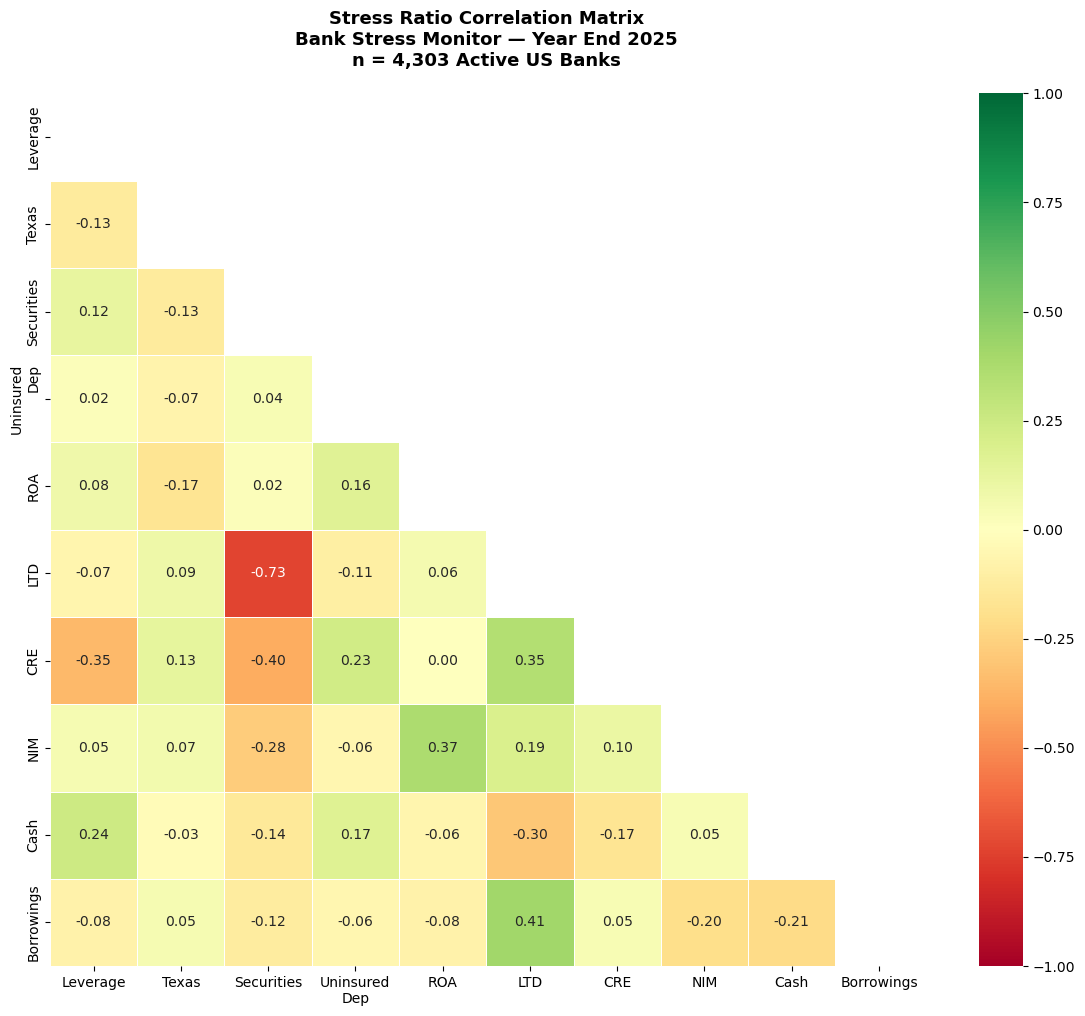


Correlation matrix saved as correlation_matrix2.png


In [40]:
# ============================================================
# CELL 16: CORRELATION MATRIX — 10 STRESS RATIOS
# ============================================================
# Purpose: Check for redundancy between ratios
#          High correlation (>0.7 absolute) means two ratios
#          may be measuring similar things — potential
#          double-counting in composite score
#
# Finding: SECURITIES_RATIO vs LTD_RATIO = -0.77
#          Negative correlation reflects balance sheet
#          tradeoff — banks heavy in securities have fewer
#          loans, banks heavy in loans have fewer securities
#          Both retained — capture distinct stress mechanisms:
#          rate risk (securities) vs liquidity (lending)
#
# All other pairs below 0.5 threshold — no redundancy issues
# ============================================================

corr_matrix = ratios_df[ratio_cols].corr()

# Print correlation matrix
print("CORRELATION MATRIX — 10 STRESS RATIOS")
print("=" * 60)
print(corr_matrix.round(2).to_string())

# Flag notable correlations
print("\n\nNOTABLE CORRELATIONS (absolute value > 0.5):")
print("-" * 55)
found_notable = False
for i in range(len(ratio_cols)):
    for j in range(i+1, len(ratio_cols)):
        corr_val = corr_matrix.iloc[i,j]
        if abs(corr_val) > 0.5:
            direction = "positive" if corr_val > 0 else "negative"
            print(f"  {ratio_cols[i]} vs {ratio_cols[j]}: "
                  f"{corr_val:.3f} ({direction})")
            found_notable = True

if not found_notable:
    print("  None found above 0.5 threshold ✅")

print(f"\nDecision: SECURITIES_RATIO vs LTD_RATIO (-0.77)")
print(f"  Both ratios retained — distinct stress mechanisms:")
print(f"  SECURITIES_RATIO → rate risk (SVB-type exposure)")
print(f"  LTD_RATIO        → structural liquidity stress")
print(f"  Negative correlation reflects natural balance sheet")
print(f"  tradeoff, not redundancy in stress measurement")

# Heatmap
fig, ax = plt.subplots(figsize=(12, 10))

# Short labels for readability
short_labels = [
    'Leverage', 'Texas', 'Securities',
    'Uninsured\nDep', 'ROA', 'LTD',
    'CRE', 'NIM', 'Cash', 'Borrowings'
]

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    xticklabels=short_labels,
    yticklabels=short_labels,
    ax=ax
)

ax.set_title(
    'Stress Ratio Correlation Matrix\n'
    'Bank Stress Monitor — Year End 2025\n'
    'n = 4,303 Active US Banks',
    fontsize=13,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.savefig('correlation_matrix2.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nCorrelation matrix saved as correlation_matrix2.png")

In [43]:
# ============================================================
# CELL 17: METHODOLOGY NOTES
# ============================================================
# Purpose: Add structured flags and notes to each bank
#          documents known limitations, special cases,
#          and data quality issues at the bank level
#          These notes will appear on the final watchlist
#
# Flags:
#   NEGATIVE_TCE:     Bank has negative tangible equity
#   LOW_COMPLETENESS: Fewer than 6 of 10 ratios available
#   FOREIGN_BRANCH:   Foreign bank US branch — partial data
#   HIGH_CRE:         CRE ratio exceeds 300% regulatory threshold
#   SPECIALTY_BANK:   Business model may distort certain ratios
# ============================================================

# Initialize notes column
ratios_df['METHODOLOGY_NOTES'] = ''

# --- Flag 1: Negative TCE (already calculated) ---
mask = ratios_df['NEGATIVE_TCE']
ratios_df.loc[mask, 'METHODOLOGY_NOTES'] += 'NEGATIVE_TCE; '
print(f"Negative TCE flag:     {mask.sum()} banks")

# --- Flag 2: Low data completeness ---
mask = ratios_df['COMPLETENESS_TIER'] == 'Low'
ratios_df.loc[mask, 'METHODOLOGY_NOTES'] += 'LOW_COMPLETENESS; '
print(f"Low completeness flag: {mask.sum()} banks")

# --- Flag 3: Foreign bank branches ---
# Identified from completeness analysis — all 9 low
# completeness banks are foreign institutions
foreign_keywords = [
    'Bank of China', 'Bank of India', 'Bank of East Asia',
    'Bank of Baroda', 'State Bank of India', 'Mizrahi',
    'Bank Hapoalim', 'Metropolitan Bank and Trust',
    'Mashreq'
]
foreign_mask = ratios_df['NAME'].str.contains(
    '|'.join(foreign_keywords), case=False, na=False
)
ratios_df.loc[foreign_mask, 'METHODOLOGY_NOTES'] += 'FOREIGN_BRANCH; '
print(f"Foreign branch flag:   {foreign_mask.sum()} banks")

# --- Flag 4: CRE above 300% regulatory threshold ---
mask = ratios_df['CRE_RATIO'] > 3.0
ratios_df.loc[mask, 'METHODOLOGY_NOTES'] += 'HIGH_CRE_CONCENTRATION; '
print(f"High CRE flag:         {mask.sum()} banks")

# --- Flag 5: Specialty banks ---
# Custodian banks, trust companies, credit card banks
# whose business model naturally distorts certain ratios
specialty_keywords = [
    'State Street', 'Northern Trust', 'BNY Mellon',
    'Schwab', 'Synchrony', 'Barclays', 'American Express',
    'Toyota', 'Goldman Sachs', 'Morgan Stanley',
    'Ameriprise', 'Boston Trust'
]
specialty_mask = ratios_df['NAME'].str.contains(
    '|'.join(specialty_keywords), case=False, na=False
)
ratios_df.loc[specialty_mask, 'METHODOLOGY_NOTES'] += 'SPECIALTY_BANK; '
print(f"Specialty bank flag:   {specialty_mask.sum()} banks")

# Clean up trailing semicolons
ratios_df['METHODOLOGY_NOTES'] = (
    ratios_df['METHODOLOGY_NOTES'].str.rstrip('; ')
)

# Replace empty strings with 'None'
ratios_df['METHODOLOGY_NOTES'] = ratios_df['METHODOLOGY_NOTES'].replace(
    '', 'None'
)

# Summary
print(f"\nMETHODOLOGY NOTES SUMMARY")
print("=" * 50)
flagged = ratios_df[ratios_df['METHODOLOGY_NOTES'] != 'None']
print(f"Total flagged banks:   {len(flagged)}")
print(f"Total clean banks:     {(ratios_df['METHODOLOGY_NOTES'] == 'None').sum()}")

print(f"\nSample flagged banks:")
print(f"{'Name':<45} {'Notes'}")
print("-" * 80)
for _, row in flagged.head(15).iterrows():
    print(f"  {str(row['NAME']):<43} {row['METHODOLOGY_NOTES']}")

Negative TCE flag:     1 banks
Low completeness flag: 9 banks
Foreign branch flag:   16 banks
High CRE flag:         848 banks
Specialty bank flag:   17 banks

METHODOLOGY NOTES SUMMARY
Total flagged banks:   879
Total clean banks:     3424

Sample flagged banks:
Name                                          Notes
--------------------------------------------------------------------------------
  Security Bank                               HIGH_CRE_CONCENTRATION
  First Southern Bank                         HIGH_CRE_CONCENTRATION
  Bank Michigan                               HIGH_CRE_CONCENTRATION
  ChoiceOne Bank                              HIGH_CRE_CONCENTRATION
  The Shelby State Bank                       HIGH_CRE_CONCENTRATION
  Sherburne State Bank                        HIGH_CRE_CONCENTRATION
  PrinsBank                                   HIGH_CRE_CONCENTRATION
  Hometown Community Bank                     HIGH_CRE_CONCENTRATION
  Builtwell Bank                              HIGH_

In [45]:
# ============================================================
# CELL 18: SAVE CLEAN DATASET TO CSV
# ============================================================
# Purpose: Export final cleaned dataset for Phase 3
#          This is the handoff file between Phase 2 and
#          Phase 3 (historical data pull + scoring model)
#
# Output columns:
#   Identifiers:    CERT, NAME, CITY, STNAME, REPDTE
#   Size:           ASSET, SIZE_TIER
#   Raw fields:     All 19 numeric FDIC fields
#   Intermediates:  NPA, TCE, TOTAL_CAP, CRE_LOANS
#   10 Ratios:      All ratio columns
#   Quality flags:  NEGATIVE_TCE, RATIOS_AVAILABLE,
#                   DATA_COMPLETENESS, COMPLETENESS_TIER,
#                   METHODOLOGY_NOTES
# ============================================================

# Define output columns
output_cols = (
    # Identifiers
    ['CERT', 'NAME', 'CITY', 'STNAME', 'REPDTE', 'ASSET', 'SIZE_TIER'] +
    # Raw fields
    ['DEP', 'DEPUNINS', 'LNLSGR', 'NETINC', 'SC', 'EQTOT',
     'INTAN', 'CHBAL', 'OTHBRF', 'RBCT1J', 'RBCT2', 'LNATRES',
     'NAASSET', 'P9ASSET', 'ORE', 'LNRECONS', 'LNRENRES', 'NIM'] +
    # Intermediate calculations
    ['NPA', 'TCE', 'TOTAL_CAP', 'CRE_LOANS'] +
    # 10 stress ratios
    ratio_cols +
    # Quality flags
    ['NEGATIVE_TCE', 'RATIOS_AVAILABLE', 'DATA_COMPLETENESS',
     'COMPLETENESS_TIER', 'METHODOLOGY_NOTES']
)

# Save to CSV
output_df = ratios_df[output_cols].copy()
output_df.to_csv('bank_stress_phase2_2025Q4.csv', index=False)

print("=" * 60)
print("PHASE 2 COMPLETE — DATASET SAVED")
print("=" * 60)
print(f"\nFile: bank_stress_phase2_2025Q4.csv")
print(f"Rows: {len(output_df):,} banks")
print(f"Columns: {len(output_cols)}")
print(f"\nDataset Summary:")
print(f"  Reporting date:      Q4 2025 (20251231)")
print(f"  Active banks:        {len(output_df):,}")
print(f"  Size tiers:          4")
print(f"  Stress ratios:       {len(ratio_cols)}")
print(f"  Risk categories:     7")
print(f"  High completeness:   "
      f"{(output_df['COMPLETENESS_TIER'] == 'High').sum():,} banks "
      f"({100*(output_df['COMPLETENESS_TIER'] == 'High').mean():.1f}%)")
print(f"  Negative TCE:        "
      f"{output_df['NEGATIVE_TCE'].sum()} bank")
print(f"  High CRE (>300%):    "
      f"{(output_df['CRE_RATIO'] > 3.0).sum()} banks")
print(f"  Foreign branches:    16 banks")
print(f"  Specialty banks:     17 banks")
print(f"\nReady for Phase 3: Historical data pull + scoring model")

PHASE 2 COMPLETE — DATASET SAVED

File: bank_stress_phase2_2025Q4.csv
Rows: 4,303 banks
Columns: 44

Dataset Summary:
  Reporting date:      Q4 2025 (20251231)
  Active banks:        4,303
  Size tiers:          4
  Stress ratios:       10
  Risk categories:     7
  High completeness:   4,294 banks (99.8%)
  Negative TCE:        1 bank
  High CRE (>300%):    848 banks
  Foreign branches:    16 banks
  Specialty banks:     17 banks

Ready for Phase 3: Historical data pull + scoring model
